# 🎥 Video 01: RDKit Fundamentals & Molecular Representations
**RDKit Masterclass — From Zero to Drug Discovery AI**
* **Duration:** ~25 - 30 Minutes
* **Curriculum Level:** LEVEL 1 — RDKit Fundamentals (Topics 01, 02, 03, 04)
* **Target Audience:** Cheminformatics Engineers, AI for Drug Discovery Researchers, Computational Chemists

---

### ⏱️ Video Agenda & Timestamps
* **00:00 - 04:30** | Introduction: What is RDKit? Cheminformatics vs Bioinformatics
* **04:30 - 09:00** | RDKit Architecture & The Core `Mol` Object (Atoms, Bonds, Rings)
* **09:00 - 14:00** | Molecular Representations: SMILES, SMARTS, MolBlock, InChI & InChIKey
* **14:00 - 19:30** | Converting SMILES to Mol: Validation, Implicit Hydrogens & Sanitization
* **19:30 - 24:00** | Converting Mol to SMILES: Canonicalization, Kekulization & Aromaticity Models
* **24:00 - 28:00** | Live Coding Exercise: Analyzing Blockbuster Drug Molecules
* **28:00 - 30:00** | Summary, Common Pitfalls & Next Episode Teaser

---

### 🎯 Learning Objectives
1. Understand RDKit's C++ core with Python bindings architecture.
2. Distinguish between 1D (SMILES/InChI), 2D (MolBlock/SDF), and 3D molecular representations.
3. Master `Chem.MolFromSmiles()` and handle invalid SMILES gracefully without script crashes.
4. Understand canonical SMILES, isomeric SMILES, and the difference between Kekule and aromatic forms.
5. Inspect individual atoms and bonds programmatically.

In [1]:
# Step 0: Environment Verification and Imports
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import pandas as pd

# Configure high-resolution inline rendering for Jupyter
IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (350, 250)

print(f"✅ RDKit Version: {rdkit.__version__}")
print("Environment initialized successfully!")

✅ RDKit Version: 2026.03.6
Environment initialized successfully!


## 1. What is RDKit & What is a `Mol` Object?
In bioinformatics, we represent biological macromolecules (DNA, RNA, proteins) primarily as **linear 1D sequences** of characters ($A, C, G, T$ or 20 amino acid letters).
In **cheminformatics**, small drug molecules are **2D/3D chemical graphs**:
* **Nodes:** Atoms (Carbon, Nitrogen, Oxygen, Halogens, etc.) with specific oxidation states, formal charges, and stereochemistry.
* **Edges:** Chemical bonds (single, double, triple, aromatic) with geometric configurations (cis/trans, stereochemical wedges).

In RDKit, every molecule is represented as an instance of `rdkit.Chem.rdchem.Mol`.

Object type: <class 'rdkit.Chem.rdchem.Mol'>
Number of heavy atoms: 13
Number of bonds: 13


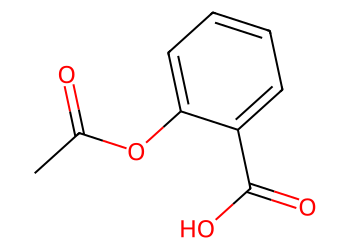

In [2]:
# Create our first molecule: Aspirin (Acetylsalicylic acid)
aspirin_smiles = "CC(=O)Oc1ccccc1C(=O)O"
mol_aspirin = Chem.MolFromSmiles(aspirin_smiles)

print(f"Object type: {type(mol_aspirin)}")
print(f"Number of heavy atoms: {mol_aspirin.GetNumAtoms()}")
print(f"Number of bonds: {mol_aspirin.GetNumBonds()}")

# Display the 2D depiction inline
mol_aspirin

## 2. Inspecting Atoms, Bonds, and Rings
Let's explore the graph structure of our molecule. We can iterate over all atoms and bonds to extract fundamental chemical properties.

In [3]:
# Inspecting atoms
atom_data = []
for atom in mol_aspirin.GetAtoms():
    atom_data.append({
        "Index": atom.GetIdx(),
        "Symbol": atom.GetSymbol(),
        "AtomicNum": atom.GetAtomicNum(),
        "FormalCharge": atom.GetFormalCharge(),
        "Hybridization": str(atom.GetHybridization()),
        "IsAromatic": atom.GetIsAromatic(),
        "TotalNumHs": atom.GetTotalNumHs(),
        "InRing": atom.IsInRing()
    })

df_atoms = pd.DataFrame(atom_data)
df_atoms.head(10)

,Index,Symbol,AtomicNum,FormalCharge,Hybridization,IsAromatic,TotalNumHs,InRing
0,0,C,6,0,SP3,False,3,False
1,1,C,6,0,SP2,False,0,False
2,2,O,8,0,SP2,False,0,False
3,3,O,8,0,SP2,False,0,False
4,4,C,6,0,SP2,True,0,True
5,5,C,6,0,SP2,True,1,True
6,6,C,6,0,SP2,True,1,True
7,7,C,6,0,SP2,True,1,True
8,8,C,6,0,SP2,True,1,True
9,9,C,6,0,SP2,True,0,True


In [4]:
# Inspecting chemical bonds
bond_data = []
for bond in mol_aspirin.GetBonds():
    bond_data.append({
        "BondIdx": bond.GetIdx(),
        "BeginAtom": f"{bond.GetBeginAtom().GetSymbol()}_{bond.GetBeginAtomIdx()}",
        "EndAtom": f"{bond.GetEndAtom().GetSymbol()}_{bond.GetEndAtomIdx()}",
        "BondType": str(bond.GetBondType()),
        "IsAromatic": bond.GetIsAromatic(),
        "IsConjugated": bond.GetIsConjugated()
    })

df_bonds = pd.DataFrame(bond_data)
df_bonds.head(10)

,BondIdx,BeginAtom,EndAtom,BondType,IsAromatic,IsConjugated
0,0,C_0,C_1,SINGLE,False,False
1,1,C_1,O_2,DOUBLE,False,True
2,2,C_1,O_3,SINGLE,False,True
3,3,O_3,C_4,SINGLE,False,True
4,4,C_4,C_5,AROMATIC,True,True
5,5,C_5,C_6,AROMATIC,True,True
6,6,C_6,C_7,AROMATIC,True,True
7,7,C_7,C_8,AROMATIC,True,True
8,8,C_8,C_9,AROMATIC,True,True
9,9,C_9,C_10,SINGLE,False,True


## 3. SMILES, InChI, and InChIKey
Different notations exist to represent chemical structures:
1. **SMILES (Simplified Molecular Input Line Entry System):** Human-readable, compact, graph-traversal string.
2. **InChI (International Chemical Identifier):** Layered IUPAC standard string describing formula, connectivity, hydrogens, charge, and stereochemistry.
3. **InChIKey:** Fixed-length 27-character SHA-256 hash of the InChI string, ideal for database indexing, search engines, and web queries.

In [5]:
# Generate canonical SMILES, InChI, and InChIKey
canonical_smiles = Chem.MolToSmiles(mol_aspirin)
inchi = Chem.MolToInchi(mol_aspirin)
inchikey = Chem.MolToInchiKey(mol_aspirin)

print(f"Canonical SMILES: {canonical_smiles}")
print(f"InChI:            {inchi}")
print(f"InChIKey:         {inchikey}")

Canonical SMILES: CC(=O)Oc1ccccc1C(=O)O
InChI:            InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)12/h2-5H,1H3,(H,11,12)
InChIKey:         BSYNRYMUTXBXSQ-UHFFFAOYSA-N


## 4. Handling Invalid SMILES & Error Recovery
In real-world data science, datasets contain typos, broken SMILES, or chemically impossible valences (e.g. 5-valent carbon).
By default, `Chem.MolFromSmiles()` prints an error to stderr and returns `None`. Your code must handle `None` gracefully!

In [6]:
# Testing valid and invalid SMILES
test_smiles = [
    ("Aspirin", "CC(=O)Oc1ccccc1C(=O)O"),
    ("Ibuprofen", "CC(C)Cc1ccc(cc1)C(C)C(=O)O"),
    ("Invalid Valence Carbon", "C(=O)(=O)(=O)C"), # Impossible pentavalent/hexavalent carbon
    ("Broken Syntax", "c1ccccc"),                 # Unclosed ring
    ("Paracetamol", "CC(=O)Nc1ccc(O)cc1")
]

parsed_molecules = {}
for name, smi in test_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"❌ Failed to parse '{name}': invalid SMILES -> {smi}")
        parsed_molecules[name] = None
    else:
        print(f"✅ Successfully parsed '{name}': {mol.GetNumAtoms()} heavy atoms")
        parsed_molecules[name] = mol

✅ Successfully parsed 'Aspirin': 13 heavy atoms
✅ Successfully parsed 'Ibuprofen': 15 heavy atoms
❌ Failed to parse 'Invalid Valence Carbon': invalid SMILES -> C(=O)(=O)(=O)C
❌ Failed to parse 'Broken Syntax': invalid SMILES -> c1ccccc
✅ Successfully parsed 'Paracetamol': 11 heavy atoms


[19:26:10] Explicit valence for atom # 0 C, 7, is greater than permitted
[19:26:10] SMILES Parse Error: unclosed ring for input: 'c1ccccc'


## 5. Canonicalization, Kekulization & Aromaticity
A single chemical compound can be written in many non-canonical SMILES forms.
For example, ethanol can be `CCO`, `OCC`, or `C(O)C`.
RDKit canonicalizes all variations to a single unique string!

Furthermore, aromatic systems can be represented in **aromatic form** (`c1ccccc1`) or **Kekule form** with alternating single and double bonds (`C1=CC=CC=C1`).

In [7]:
# Multiple SMILES representing the same compound
smi_variants = ["CCO", "OCC", "C(O)C"]
for s in smi_variants:
    m = Chem.MolFromSmiles(s)
    print(f"Input: {s:<8} -> Canonical: {Chem.MolToSmiles(m)}")

# Kekulization vs Aromatic SMILES
benzene = Chem.MolFromSmiles("c1ccccc1")
print(f"Standard Aromatic SMILES: {Chem.MolToSmiles(benzene)}")

# Kekulize the molecule (assign explicit alternating single and double bonds)
Chem.Kekulize(benzene)
print(f"Kekule SMILES:           {Chem.MolToSmiles(benzene, kekuleSmiles=True)}")

Input: CCO      -> Canonical: CCO
Input: OCC      -> Canonical: CCO
Input: C(O)C    -> Canonical: CCO
Standard Aromatic SMILES: c1ccccc1
Kekule SMILES:           C1=CC=CC=C1


## 6. Isomeric SMILES & Stereochemistry
Stereochemistry is vital in pharmacology: one enantiomer may be an active life-saving drug, while the opposite enantiomer could be inactive or toxic (e.g., Thalidomide).
RDKit preserves stereochemistry using `@` and `@@` for tetrahedral chiral centers, and `/` or `\` for cis/trans double bonds.

L-Alanine Isomeric SMILES: C[C@H](N)C(=O)O
L-Alanine Non-isomeric:    CC(N)C(=O)O
D-Alanine Isomeric SMILES: C[C@@H](N)C(=O)O


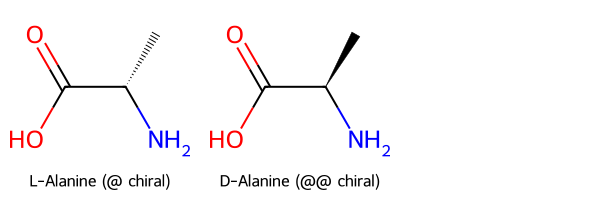

In [8]:
# L-Alanine vs D-Alanine
l_alanine = Chem.MolFromSmiles("N[C@@H](C)C(=O)O")
d_alanine = Chem.MolFromSmiles("N[C@H](C)C(=O)O")

print(f"L-Alanine Isomeric SMILES: {Chem.MolToSmiles(l_alanine, isomericSmiles=True)}")
print(f"L-Alanine Non-isomeric:    {Chem.MolToSmiles(l_alanine, isomericSmiles=False)}")
print(f"D-Alanine Isomeric SMILES: {Chem.MolToSmiles(d_alanine, isomericSmiles=True)}")

Draw.MolsToGridImage([l_alanine, d_alanine], legends=["L-Alanine (@ chiral)", "D-Alanine (@@ chiral)"])

## 7. 🎯 Video Hands-On Challenge & Solution
### Problem:
Given a list of 5 blockbuster drugs:
1. Parse each into an RDKit Mol object.
2. Extract the canonical SMILES, molecular formula, number of rings, and heavy atom count.
3. Handle any potential parsing failures safely.
4. Render them in a clean 2D comparison grid!

=== BLOCKBUSTER DRUGS SUMMARY TABLE ===


,Drug,Formula,HeavyAtoms,Rings
0,Caffeine,C8H10N4O2,14,2
1,Imatinib (Gleevec),C29H31N7O,37,5
2,Atorvastatin (Lipitor),C33H35FN2O5,41,4
3,Penicillin V,C16H18N2O5S,24,3
4,Gefitinib (Iressa),C22H24ClFN4O3,31,4


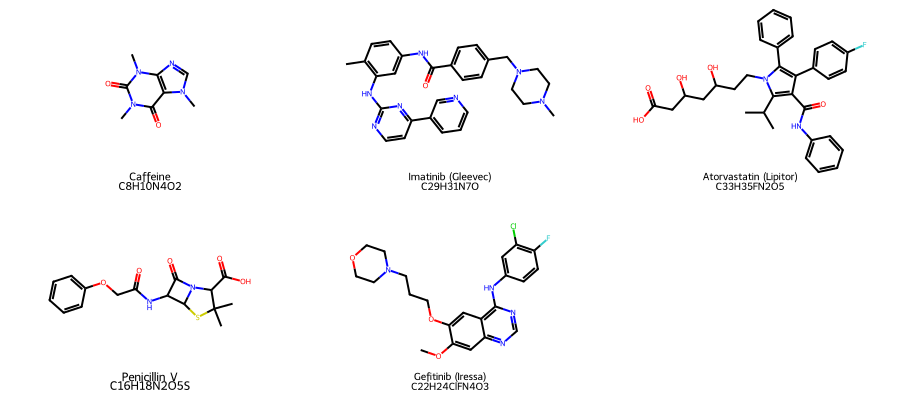

In [9]:
from rdkit.Chem import rdMolDescriptors

drugs = {
    "Caffeine": "Cn1cnc2c1c(=O)n(c(=O)n2C)C",
    "Imatinib (Gleevec)": "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C",
    "Atorvastatin (Lipitor)": "CC(C)c1c(C(=O)Nc2ccccc2)c(c3ccc(F)cc3)c(c4ccccc4)n1CCC(O)CC(O)CC(=O)O",
    "Penicillin V": "CC1(C(N2C(S1)C(C2=O)NC(=O)COc3ccccc3)C(=O)O)C",
    "Gefitinib (Iressa)": "COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN4CCOCC4"
}

results = []
valid_mols = []
legends = []

for name, smi in drugs.items():
    mol = Chem.MolFromSmiles(smi)
    if mol:
        formula = rdMolDescriptors.CalcMolFormula(mol)
        num_rings = rdMolDescriptors.CalcNumRings(mol)
        canon_smi = Chem.MolToSmiles(mol)
        
        results.append({
            "Drug": name,
            "Formula": formula,
            "HeavyAtoms": mol.GetNumAtoms(),
            "Rings": num_rings,
            "Canonical_SMILES": canon_smi
        })
        valid_mols.append(mol)
        legends.append(f"{name}\n{formula}")

df_results = pd.DataFrame(results)
print("=== BLOCKBUSTER DRUGS SUMMARY TABLE ===")
display(df_results[["Drug", "Formula", "HeavyAtoms", "Rings"]])

# Display 2D grid image
Draw.MolsToGridImage(valid_mols, legends=legends, molsPerRow=3, subImgSize=(300, 200))

## 8. Summary & Key Takeaways
* **`Mol` Graph Object:** RDKit represents molecules as rich chemical graphs where atoms are nodes and bonds are edges.
* **SMILES Parsing:** Always check `if mol is None:` when loading SMILES from untrusted sources or public datasets.
* **Canonicalization:** Standardize molecule representations across databases using canonical SMILES or InChIKeys.
* **Stereochemistry:** Retain crucial 3D spatial arrangements using `isomericSmiles=True`.

**Next Up in Video 02:** We will dive into **Molecular File Formats & I/O Operations** — reading and writing multi-compound SDF, MOL, SMI files, and integrating with Pandas!